In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np
pd.set_option("display.max_columns", None)

In [2]:
metaData = pd.read_excel('donorMetadata.xlsx',dtype={"TXSTDonorNumber": str})
# make sure it's string
metaData["TXSTDonorNumber"] = metaData["TXSTDonorNumber"].astype(str)

metaData["TXSTDonorNumber"] = metaData["TXSTDonorNumber"].replace(
    {
        "2014.02": "2014.020",
        "2015.03": "2015.030"
    }
)
metaData.to_csv('donorMetadata.csv', index=False)
weather= pd.read_csv('FreemanRanchWeather_cleaned.csv')

In [3]:
metaData['filename'].nunique()

504

In [4]:
donors = metaData['TXSTDonorNumber'].astype(str).unique()
len(donors)

36

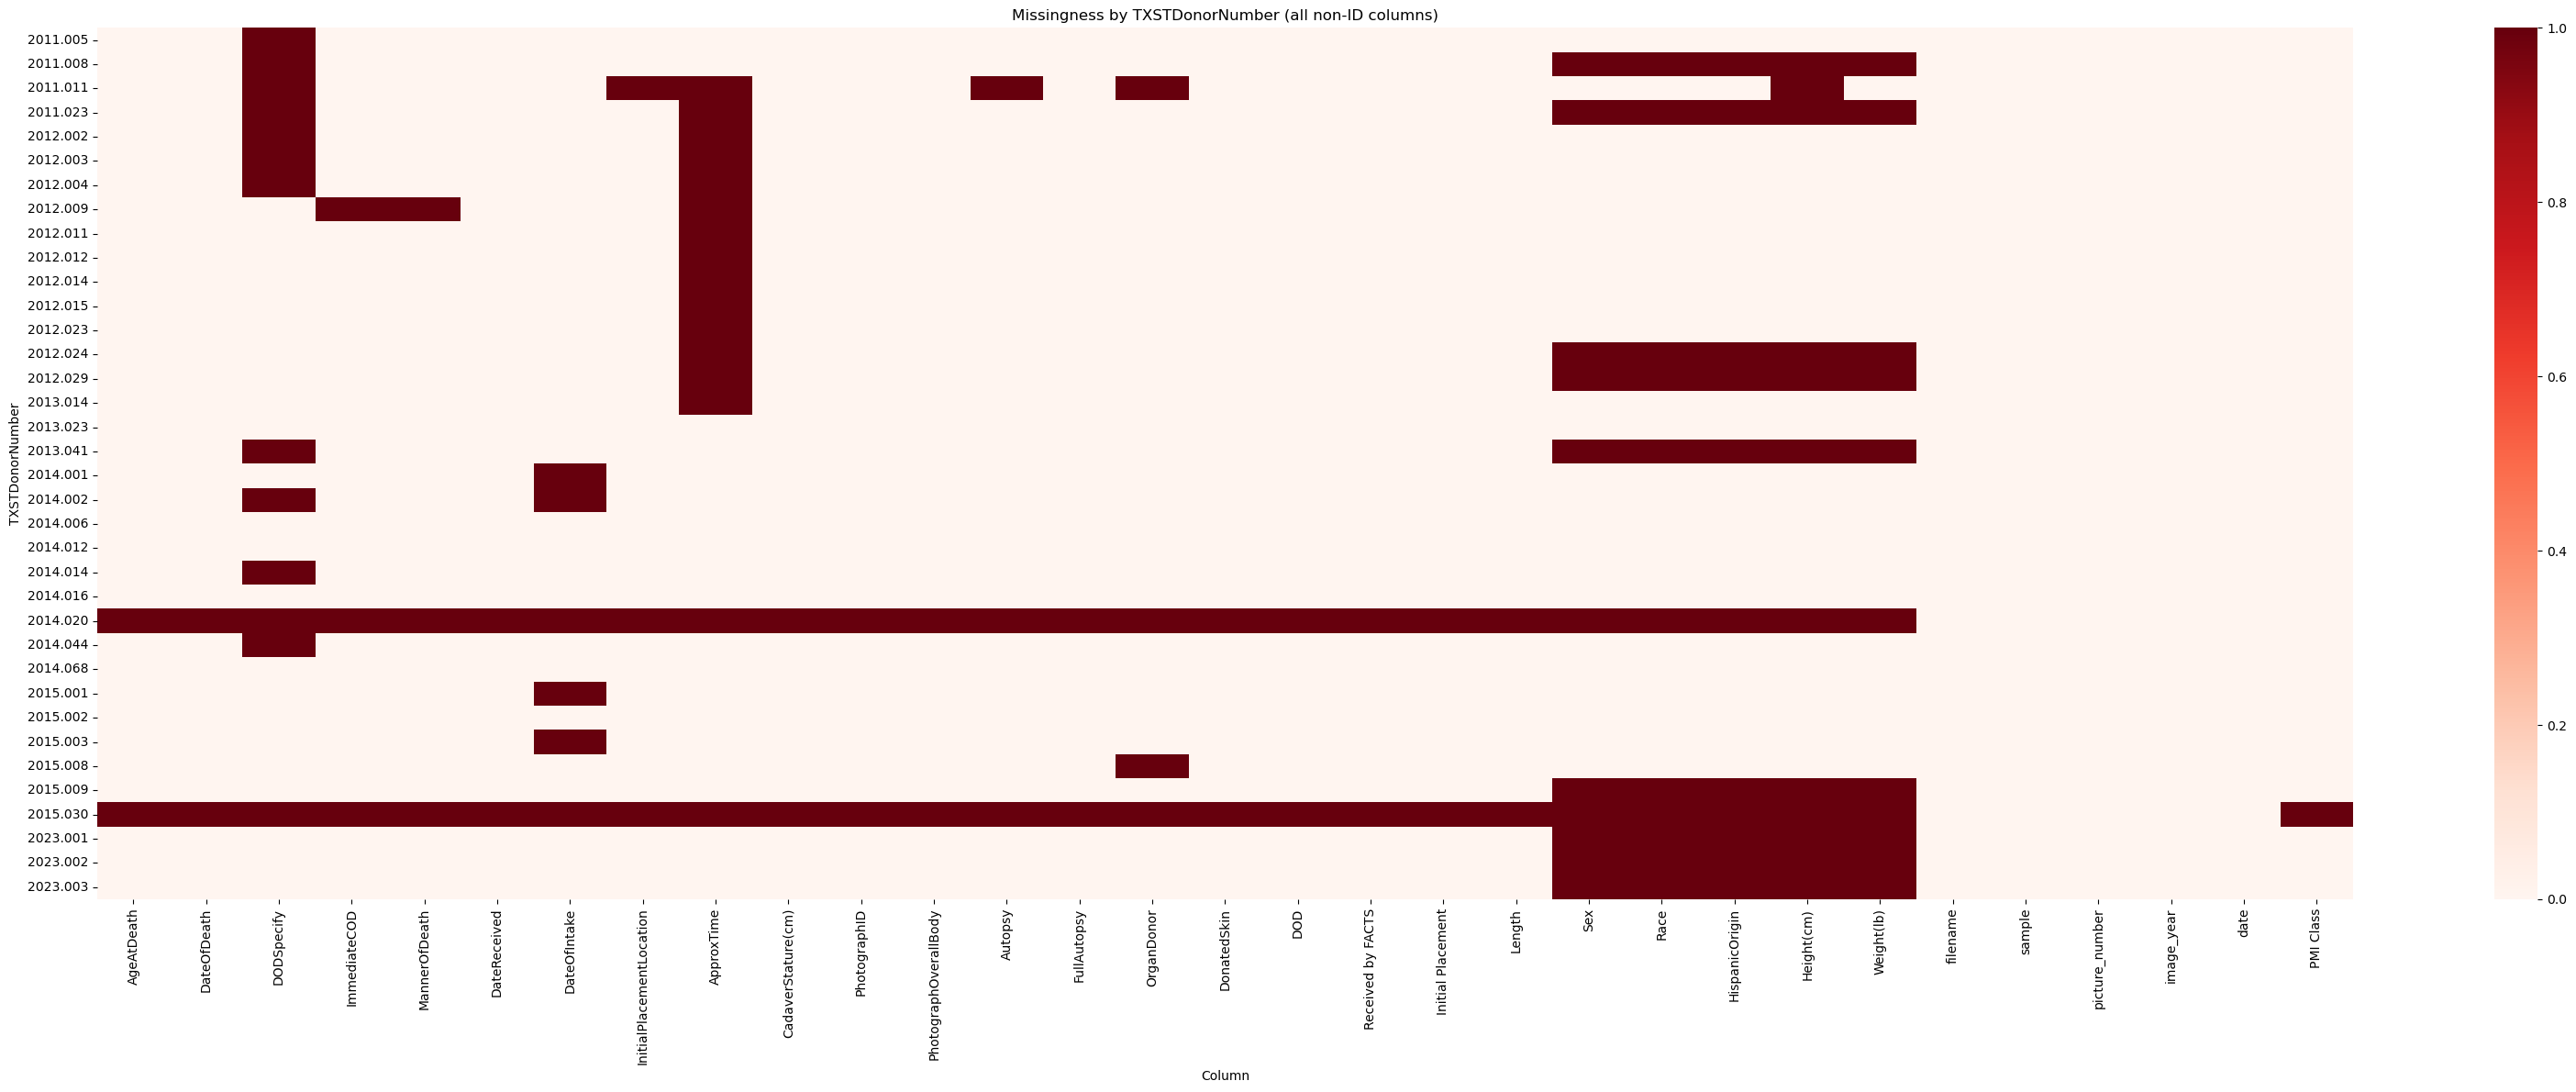

In [5]:
cols_to_check = [c for c in metaData.columns if c != "TXSTDonorNumber"]

miss = metaData.set_index("TXSTDonorNumber")[cols_to_check].isna().astype(int)
miss_by_donor = miss.groupby("TXSTDonorNumber").max()

plt.figure(figsize=(32, 12))
sns.heatmap(miss_by_donor, cmap="Reds", cbar=True)
plt.title("Missingness by TXSTDonorNumber (all non-ID columns)")
plt.ylabel("TXSTDonorNumber")
plt.xlabel("Column")
plt.tight_layout()
plt.show()

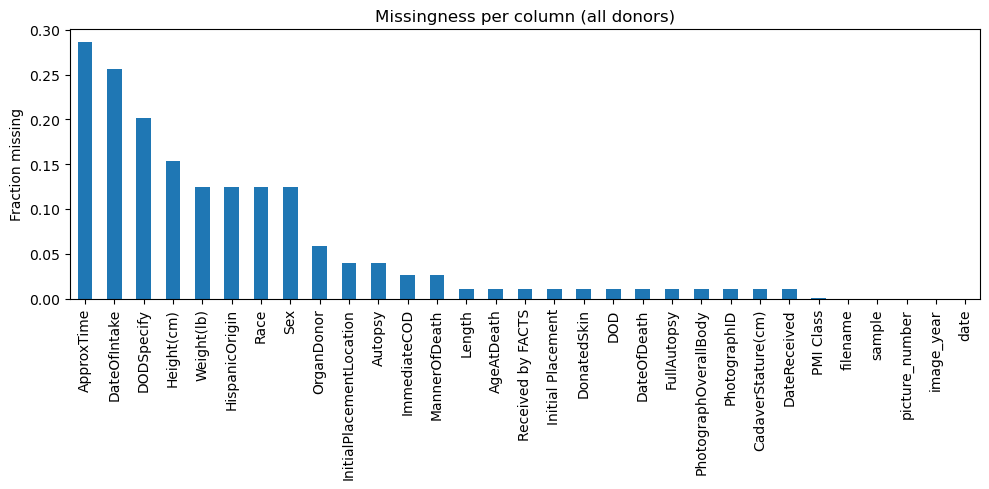

In [6]:
col_miss_pct = metaData[cols_to_check].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
col_miss_pct.plot(kind="bar")
plt.ylabel("Fraction missing")
plt.title("Missingness per column (all donors)")
plt.tight_layout()
plt.savefig('missingness_per_col.png', dpi=300, format='png')
plt.show()


In [7]:
metaData

,TXSTDonorNumber,AgeAtDeath,DateOfDeath,DODSpecify,ImmediateCOD,MannerOfDeath,DateReceived,DateOfIntake,InitialPlacementLocation,ApproxTime,CadaverStature(cm),PhotographID,PhotographOverallBody,Autopsy,FullAutopsy,OrganDonor,DonatedSkin,DOD,Received by FACTS,Initial Placement,Length,Sex,Race,HispanicOrigin,Height(cm),Weight(lb),filename,sample,picture_number,image_year,date,PMI Class
0,2011.005,80.0,2011-03-07,NaN,Alzheimer's disease,Natural,2011-03-07,2011-03-07,Burial,1332.0,178.0,0.0,0.0,No,0.0,No,0.0,2011-03-07 00:00:00,2011-03-07 00:00:00,Surface,0.0,Male,White,Non-hispanic,178.0,160.0,2011.005.03.07.2011 (15).JPG,5,15,2011,3/7/2011,1.0
1,2011.005,80.0,2011-03-07,NaN,Alzheimer's disease,Natural,2011-03-07,2011-03-07,Burial,1332.0,178.0,0.0,0.0,No,0.0,No,0.0,2011-03-07 00:00:00,2011-03-07 00:00:00,Surface,0.0,Male,White,Non-hispanic,178.0,160.0,2011.005.03.11.2011 (9).JPG,5,9,2011,3/11/2011,2.0
2,2011.005,80.0,2011-03-07,NaN,Alzheimer's disease,Natural,2011-03-07,2011-03-07,Burial,1332.0,178.0,0.0,0.0,No,0.0,No,0.0,2011-03-07 00:00:00,2011-03-07 00:00:00,Surface,0.0,Male,White,Non-hispanic,178.0,160.0,2011.005.03.15.2011 (7).jpg,5,7,2011,3/15/2011,3.0
3,2011.005,80.0,2011-03-07,NaN,Alzheimer's disease,Natural,2011-03-07,2011-03-07,Burial,1332.0,178.0,0.0,0.0,No,0.0,No,0.0,2011-03-07 00:00:00,2011-03-07 00:00:00,Surface,0.0,Male,White,Non-hispanic,178.0,160.0,2011.005.03.21.2011 (2).JPG,5,2,2011,3/21/2011,4.0
4,2011.005,80.0,2011-03-07,NaN,Alzheimer's disease,Natural,2011-03-07,2011-03-07,Burial,1332.0,178.0,0.0,0.0,No,0.0,No,0.0,2011-03-07 00:00:00,2011-03-07 00:00:00,Surface,0.0,Male,White,Non-hispanic,178.0,160.0,2011.005.03.23.2011 (1).JPG,5,1,2011,3/23/2011,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260,2023.003,35.0,2023-01-05,Actual,Acute myelocytic leukemia (AML),Natural,2023-01-09,2023-01-09,Cooler,1645.0,166.0,1.0,1.0,No,0.0,No,0.0,2023-01-05 00:00:00,2023-01-09 00:00:00,cooler @ 1645,4.0,NaN,NaN,NaN,NaN,NaN,2023.003.08.23.2023 (11).JPG,3,11,2023,8/23/2023,5.0
1261,2023.003,35.0,2023-01-05,Actual,Acute myelocytic leukemia (AML),Natural,2023-01-09,2023-01-09,Cooler,1645.0,166.0,1.0,1.0,No,0.0,No,0.0,2023-01-05 00:00:00,2023-01-09 00:00:00,cooler @ 1645,4.0,NaN,NaN,NaN,NaN,NaN,2023.003.09.13.2023 (11).JPG,3,11,2023,9/13/2023,5.0
1262,2023.003,35.0,2023-01-05,Actual,Acute myelocytic leukemia (AML),Natural,2023-01-09,2023-01-09,Cooler,1645.0,166.0,1.0,1.0,No,0.0,No,0.0,2023-01-05 00:00:00,2023-01-09 00:00:00,cooler @ 1645,4.0,NaN,NaN,NaN,NaN,NaN,2023.003.10.18.2023 (12).JPG,3,12,2023,10/18/2023,5.0
1263,2023.003,35.0,2023-01-05,Actual,Acute myelocytic leukemia (AML),Natural,2023-01-09,2023-01-09,Cooler,1645.0,166.0,1.0,1.0,No,0.0,No,0.0,2023-01-05 00:00:00,2023-01-09 00:00:00,cooler @ 1645,4.0,NaN,NaN,NaN,NaN,NaN,2023.003.11.15.2023 (12).JPG,3,12,2023,11/15/2023,5.0


In [14]:
weather

,date,time,Temp_Out,temp_high,temp_low,humidity_out,dew_point,wind_speed,wind_dir,Wind_Run,Hi_Speed,Hi_Dir,Wind_Chill,Heat_Index,THW_Index,THSW_Bar,THSW_Rain,rain_rate,Heat_D-D,Cool_D-D,Arc_Int,season
Date_Time,,,,,,,,,,,,,,,,,,,,,,
2015-01-01 08:00:00,2015-01-01,08:00:00,34.6,34.7,34.6,96,33.6,2,N,1.0,6,NNE,33.8,34.6,33.8,30.300,0.01,0.00,0.633,0.0,30,Winter
2015-01-01 07:00:00,2015-01-01,07:00:00,34.7,34.9,34.7,96,33.7,3,NNE,1.5,9,N,32.4,34.7,32.4,30.303,0.02,0.06,0.631,0.0,30,Winter
2015-01-01 09:00:00,2015-01-01,09:00:00,34.7,34.9,34.7,96,33.7,2,N,1.0,7,NNE,33.9,34.7,33.9,30.315,0.00,0.00,0.631,0.0,30,Winter
2015-01-01 06:00:00,2015-01-01,06:00:00,35.2,35.3,34.9,95,33.9,2,NNE,1.0,7,NNE,34.5,35.2,34.5,30.305,0.00,0.00,0.621,0.0,30,Winter
2015-01-01 05:00:00,2015-01-01,05:00:00,35.1,35.4,35.1,95,33.8,2,WNW,1.0,6,NNW,34.4,35.1,34.4,30.318,0.04,0.11,0.623,0.0,30,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 19:00:00,2015-12-31,19:00:00,49.7,49.8,49.7,74,41.7,6,NNE,3.0,10,NNE,47.3,49.4,47.0,30.301,0.00,0.00,0.319,0.0,30,Winter
2015-12-31 20:00:00,2015-12-31,20:00:00,49.5,49.7,49.5,75,41.9,7,NNE,3.5,14,NE,46.6,49.3,46.4,30.325,0.00,0.00,0.323,0.0,30,Winter
2015-12-31 21:00:00,2015-12-31,21:00:00,49.2,49.3,49.2,75,41.6,6,NNE,3.0,15,NNE,46.7,48.9,46.4,30.351,0.00,0.00,0.329,0.0,30,Winter


In [13]:
weather["Date_Time"] = pd.to_datetime(weather["date"] + " " + weather["time"])

# 2. Set datetime index
weather = weather.set_index("Date_Time")

# 3. Resample to daily
weather_daily = weather.resample("D").agg({
    "Temp_Out": "mean",
    "temp_high": "max",
    "temp_low": "min",
    "humidity_out": "mean",
    "dew_point": "mean",
    "wind_speed": "mean",
    "wind_dir": "first",        # categorical
    "Wind_Run": "sum",
    "Hi_Speed": "max",
    "Hi_Dir": "first",
    "Wind_Chill": "mean",
    "Heat_Index": "mean",
    "THW_Index": "mean",
    "THSW_Bar": "mean",
    "THSW_Rain": "mean",
    "rain_rate": "sum",
    "Heat_D-D": "sum",
    "Cool_D-D": "sum",
    "Arc_Int": "sum",
    "season": "first",
})

# 4. Keep only a Date column (no time)
weather_daily = weather_daily.reset_index()
weather_daily["Date"] = weather_daily["Date_Time"].dt.date
weather_daily = weather_daily.drop(columns=["Date_Time"], axis=1)
weather_daily

,Temp_Out,temp_high,temp_low,humidity_out,dew_point,wind_speed,wind_dir,Wind_Run,Hi_Speed,Hi_Dir,Wind_Chill,Heat_Index,THW_Index,THSW_Bar,THSW_Rain,rain_rate,Heat_D-D,Cool_D-D,Arc_Int,season,Date
0,36.791304,39.0,34.6,94.347826,35.300000,2.913043,NNE,33.5,11.0,NNE,35.008696,36.773913,34.991304,30.249174,0.005652,0.21,13.516,0.00,690,Winter,2015-01-01
1,39.783333,41.5,38.4,96.625000,38.895833,0.416667,N,5.0,12.0,NNE,39.770833,39.879167,39.866667,30.103000,0.002083,0.08,12.606,0.00,720,Winter,2015-01-02
2,46.375000,64.8,37.3,83.458333,40.675000,0.666667,ENE,8.0,11.0,NNE,46.375000,46.004167,46.004167,30.006917,0.012917,3.58,9.312,0.00,720,Winter,2015-01-03
3,42.979167,52.4,33.6,68.791667,32.708333,2.291667,---,27.5,19.0,---,42.283333,42.333333,41.637500,30.434542,0.000000,0.00,11.009,0.00,720,Winter,2015-01-04
4,37.362500,52.9,27.8,65.375000,25.883333,1.625000,N,19.5,13.0,N,36.612500,36.612500,35.862500,30.594792,0.000000,0.00,13.820,0.00,720,Winter,2015-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,50.462500,73.7,36.6,90.958333,47.858333,5.791667,SE,69.5,21.0,S,47.916667,51.112500,48.566667,29.622750,0.021250,6.79,8.299,1.03,720,Winter,2015-12-27
361,38.733333,45.4,32.6,76.208333,31.712500,5.791667,W,69.5,25.0,WNW,34.887500,38.304167,34.458333,29.912708,0.000000,0.00,13.137,0.00,720,Winter,2015-12-28
362,41.175000,48.2,32.6,85.000000,36.770833,1.583333,---,19.0,10.0,---,40.762500,40.991667,40.579167,30.045708,0.000833,0.00,11.912,0.00,720,Winter,2015-12-29
363,47.937500,57.8,41.6,87.791667,44.254167,2.333333,NNE,28.0,13.0,NNE,47.562500,47.912500,47.537500,30.185417,0.000417,0.00,8.530,0.00,720,Winter,2015-12-30


In [15]:
weather_daily.to_csv('weatherFreeman_daily.csv', index=False)

In [ ]:
caption_train = pd.read_csv('final/caption_features_train.csv')
caption_train['split']= 'train'
caption_val = pd.read_csv('final/caption_features_val.csv')
caption_val['split']= 'val'

caption_test = pd.read_csv('final/caption_features_test.csv')
caption_test['split']= 'test'
captions  = pd.concat([caption_train, caption_val, caption_test], axis=0)
captions

In [ ]:
resnet_train = pd.read_csv('final/train_resnet50_features.csv')
resnet_train['split']= 'train'

resnet_val = pd.read_csv('final/val_resnet50_features.csv')
resnet_val['split']= 'val'

resnet_test = pd.read_csv('final/test_resnet50_features.csv')
resnet_test['split']= 'test'
resnet  = pd.concat([resnet_train, resnet_val, resnet_test], axis=0)
resnet

In [ ]:
split = pd.read_csv('final/split_manifest_weather.csv')
split

In [ ]:
print('Caption cols:', captions.columns)
print('resnet cols:', resnet.columns)
print('split cols:', split.columns)

In [ ]:
captions = captions.rename(columns={"label": "class_label"})
split    = split.rename(columns={"class": "class_label",
                                 "image_path": "image"})


In [ ]:
# Make sure join keys are strings
for df in (captions, resnet, split):
    for col in ["image", "split", "stem", "year", "donor_id", "unique_donor_id", "class_label"]:
        if col in df.columns:
            df[col] = df[col].astype(str)

# ------------------------------------------------------------------
# 3. Merge captions + resnet on image & split
# ------------------------------------------------------------------
cap_res = captions.merge(
    resnet,
    on=["image", "split"],
    how="left",
    suffixes=("", "_resnet")
)

# ------------------------------------------------------------------
# 4. Merge cap_res with split (weather + metadata)
#    Use the shared identity keys: split, class_label, year, donor_id, unique_donor_id, stem
# ------------------------------------------------------------------
full = cap_res.merge(
    split,
    on=["split", "class_label", "year", "donor_id", "unique_donor_id", "stem"],
    how="left",
    suffixes=("", "_split")
)

# ------------------------------------------------------------------
# 5. Sanity checks
# ------------------------------------------------------------------
print("captions:", captions.shape)
print("resnet:  ", resnet.shape)
print("split:   ", split.shape)
print("full:    ", full.shape)
full

In [ ]:
full.to_csv('final/finalized_metadata.csv', index=False)